# Seaborn
Seaborn è una libreria di visualizzazione dei dati basata su Matplotlib che fornisce un'interfaccia di alto livello per creare grafici statistici. Seaborn semplifica la creazione di grafici complessi e offre funzionalità avanzate per l'analisi dei dati, come la visualizzazione di distribuzioni, relazioni tra variabili e modelli statistici.

A differenza di Matplotlib, Seaborn è progettato per lavorare bene con i DataFrame di Pandas e offre una serie di funzioni predefinite per visualizzare i dati in modo efficace. Seaborn include anche temi predefiniti per migliorare l'estetica dei grafici e supporta la personalizzazione avanzata.

Per utilizzare Seaborn, è necessario installarlo tramite pip:

```bash
pip install seaborn
```
Una volta installato, è possibile importare Seaborn e utilizzarlo per creare grafici. Ad esempio, per creare un grafico a dispersione con Seaborn, si può utilizzare la funzione `scatterplot`:

```python
import seaborn as sns
import matplotlib.pyplot as plt
# Esempio di utilizzo di Seaborn per creare un grafico a dispersione
sns.scatterplot(data=df, x='feature1', y='feature2')
plt.show()
```
Seaborn offre molte altre funzioni per creare diversi tipi di grafici, come `lineplot`, `barplot`, `histplot`, `boxplot`, e molti altri, che facilitano l'analisi visiva dei dati e la comprensione delle relazioni tra le variabili. Per vedere tutte le funzionalità di Seaborn, è possibile consultare la documentazione ufficiale: https://seaborn.pydata.org/


## Seaborn: Barplot
Il barplot è un tipo di grafico a barre che mostra la relazione tra una variabile categorica e una variabile numerica. In Seaborn, è possibile creare un barplot utilizzando la funzione `barplot()`. Questa funzione accetta diversi argomenti, tra cui `data`, `x`, `y`, `hue`, `palette`, e molti altri, che consentono di personalizzare il grafico in base alle esigenze.

In [7]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast


dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg
df_DA_US = df_DA_US.explode('job_skills')

Vediamo come migliorare i grafici creati con Matplotlib utilizzando Seaborn. In particolare, analizziamo le 10 skills più pagate per Data Analyst e le 10 skills più richieste per Data Analyst negli Stati Uniti, creando due grafici a barre affiancati per visualizzare queste informazioni in modo chiaro e informativo.

In [12]:
df_DA_US_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_US_top_paid = df_DA_US_grouped.sort_values(by='median', ascending=False).head(10)
df_DA_US_top_skills = df_DA_US_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

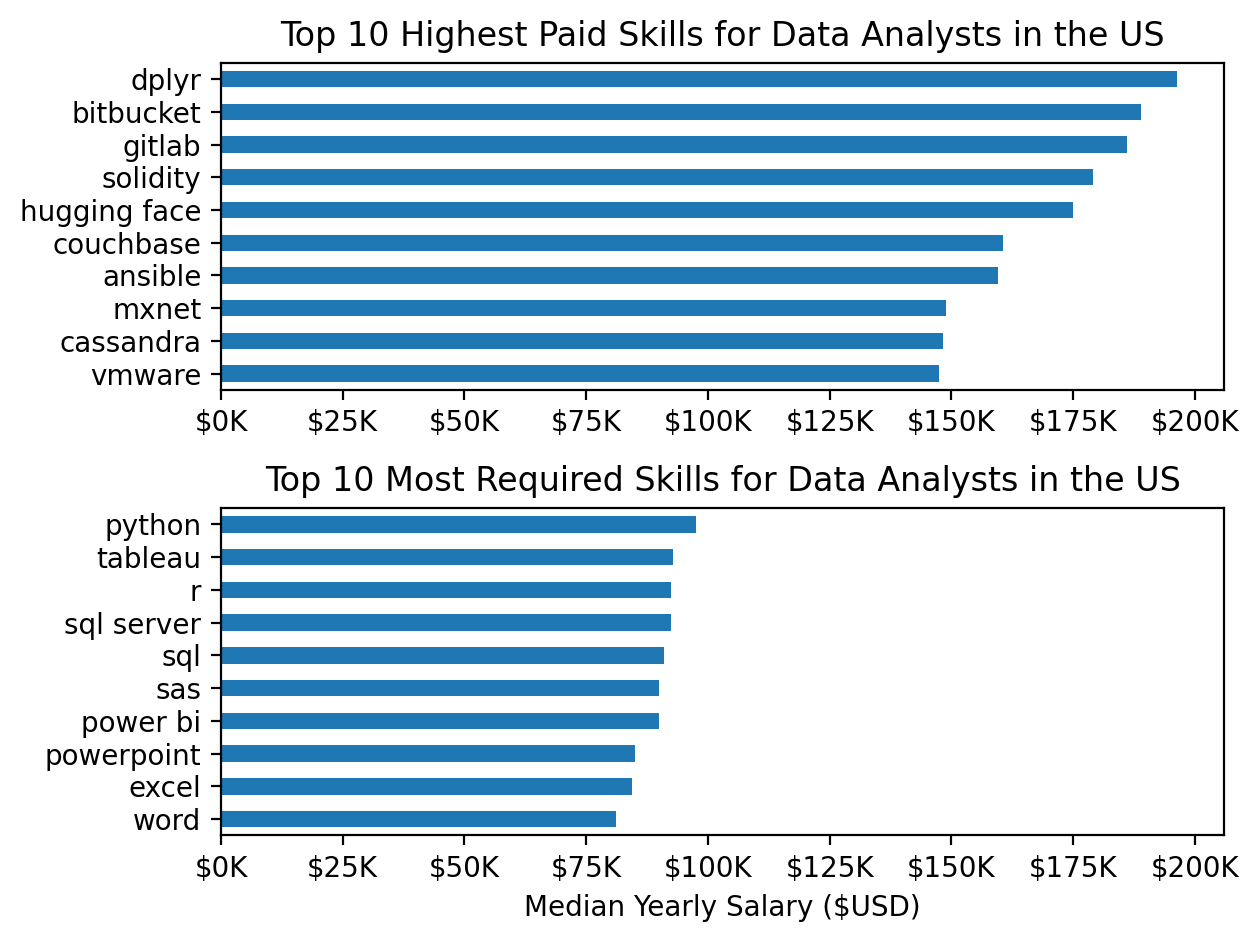

In [13]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(2, 1)
df_DA_US_top_paid.plot(kind='barh', y='median', ax=axes[0], legend=False)
axes[0].invert_yaxis() # inverte l'asse y per avere la skill più pagata in alto
axes[0].set_title("Top 10 Highest Paid Skills for Data Analysts in the US")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari

df_DA_US_top_skills.plot(kind='barh', y='median', ax=axes[1], legend=False)
axes[1].invert_yaxis() # inverte l'asse y per avere la skill più richiesta in alto
axes[1].set_title("Top 10 Most Required Skills for Data Analysts in the US")
axes[1].set_ylabel("")
axes[1].set_xlabel("Median Yearly Salary ($USD)")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari
axes[1].set_xlim(axes[0].get_xlim()) # allinea l'asse x del secondo grafico a quello del primo
fig.tight_layout()

La versione migliorata:

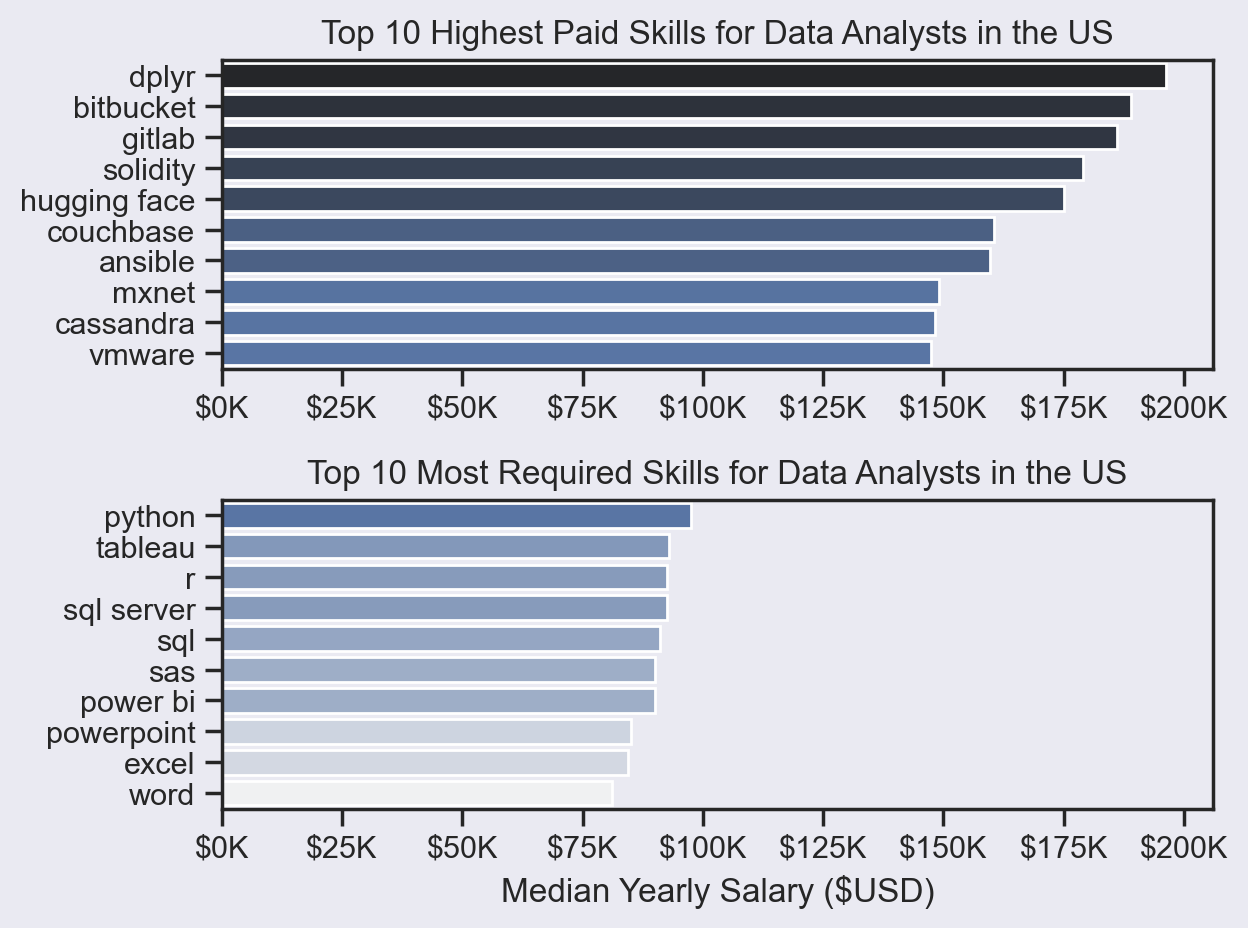

In [33]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(2, 1)
sns.set_theme(style="ticks")

sns.barplot(data=df_DA_US_top_paid, x='median', y=df_DA_US_top_paid.index, ax=axes[0], hue='median', palette='dark:b_r')
axes[0].set_title("Top 10 Highest Paid Skills for Data Analysts in the US")
axes[0].legend_.remove() # rimuove la legenda
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari


sns.barplot(data=df_DA_US_top_skills, x='median', y=df_DA_US_top_skills.index, ax=axes[1], hue='median', palette='light:b')
axes[1].set_title("Top 10 Most Required Skills for Data Analysts in the US")
axes[1].legend_.remove() # rimuove la legenda
axes[1].set_ylabel("")
axes[1].set_xlabel("Median Yearly Salary ($USD)")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari
axes[1].set_xlim(axes[0].get_xlim()) # allinea l'asse x del secondo grafico a quello del primo
fig.tight_layout()

# Seaborn: Histogram e displot
L'istogramma è un tipo di grafico che mostra la distribuzione di una variabile numerica. In Seaborn, è possibile creare un istogramma utilizzando la funzione `histplot()`, che offre molte opzioni per personalizzare l'aspetto del grafico e per visualizzare la distribuzione dei dati in modo efficace. Inoltre, Seaborn offre la funzione `displot()`, che consente di creare grafici di distribuzione più complessi, come grafici a più pannelli o grafici con stime di densità. Queste funzioni sono particolarmente utili per analizzare la distribuzione dei dati e identificare eventuali pattern o anomalie. Per ulteriori dettagli su come utilizzare `histplot()` e `displot()`, è possibile consultare la documentazione ufficiale di Seaborn: https://seaborn.pydata.org/generated/seaborn.histplot.html e https://seaborn.pydata.org/generated/seaborn.displot.html.

Con matplotlib avevamo:

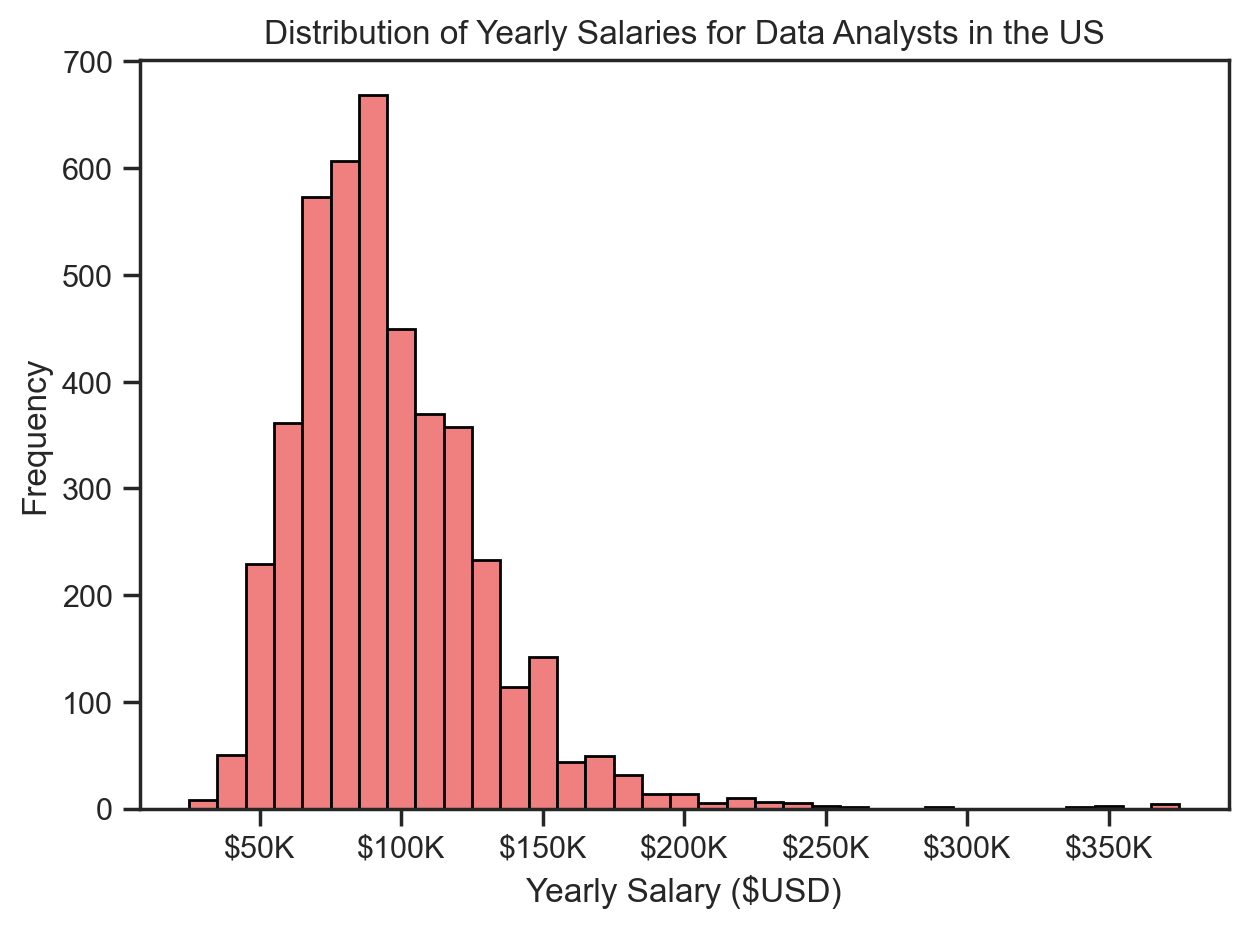

In [44]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg

df_DA_US['salary_year_avg'].plot(
    kind='hist', 
    bins=35, 
    title="Distribution of Yearly Salaries for Data Analysts in the US", 
    color='lightcoral',
    edgecolor='black' # aggiunge un bordo nero alle barre per migliorare la leggibilità
)
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("Frequency")
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


Vediamo ora come migliorare l'istogramma con Seaborn.

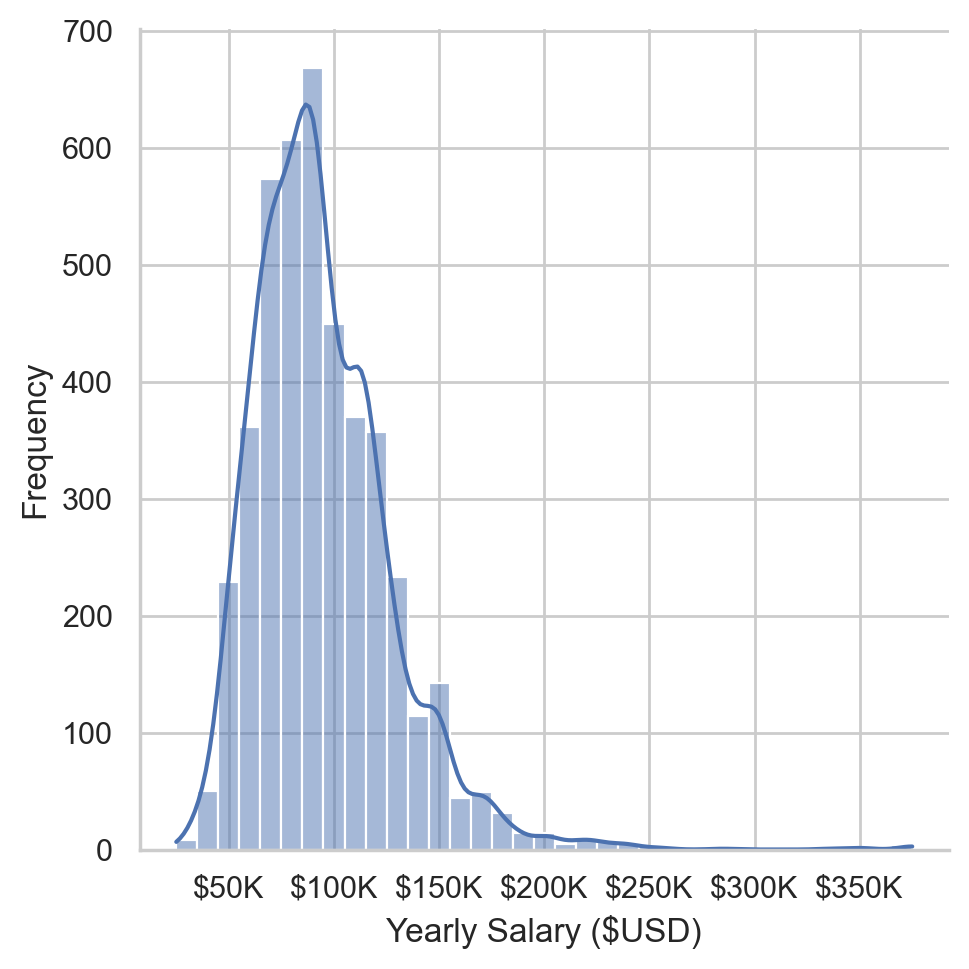

In [48]:
import seaborn as sns
sns.displot(df_DA_US, x='salary_year_avg', bins=35, kde=True)
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("Frequency")
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

## Seaborn: Boxplot
Il boxplot, o grafico a scatola, è un tipo di grafico che mostra la distribuzione di una variabile numerica attraverso i suoi quartili, evidenziando anche eventuali outlier. In Seaborn, è possibile creare un boxplot utilizzando la funzione `boxplot()`, che consente di visualizzare la distribuzione dei dati in modo chiaro e informativo. Il boxplot è particolarmente utile per confrontare la distribuzione di una variabile numerica tra diverse categorie, identificare la presenza di outlier e comprendere la variabilità dei dati. Per ulteriori dettagli su come utilizzare `boxplot()`, è possibile consultare la documentazione ufficiale di Seaborn: https://seaborn.pydata.org/generated/seaborn.boxplot.html.

Con matplotlib avevamo:

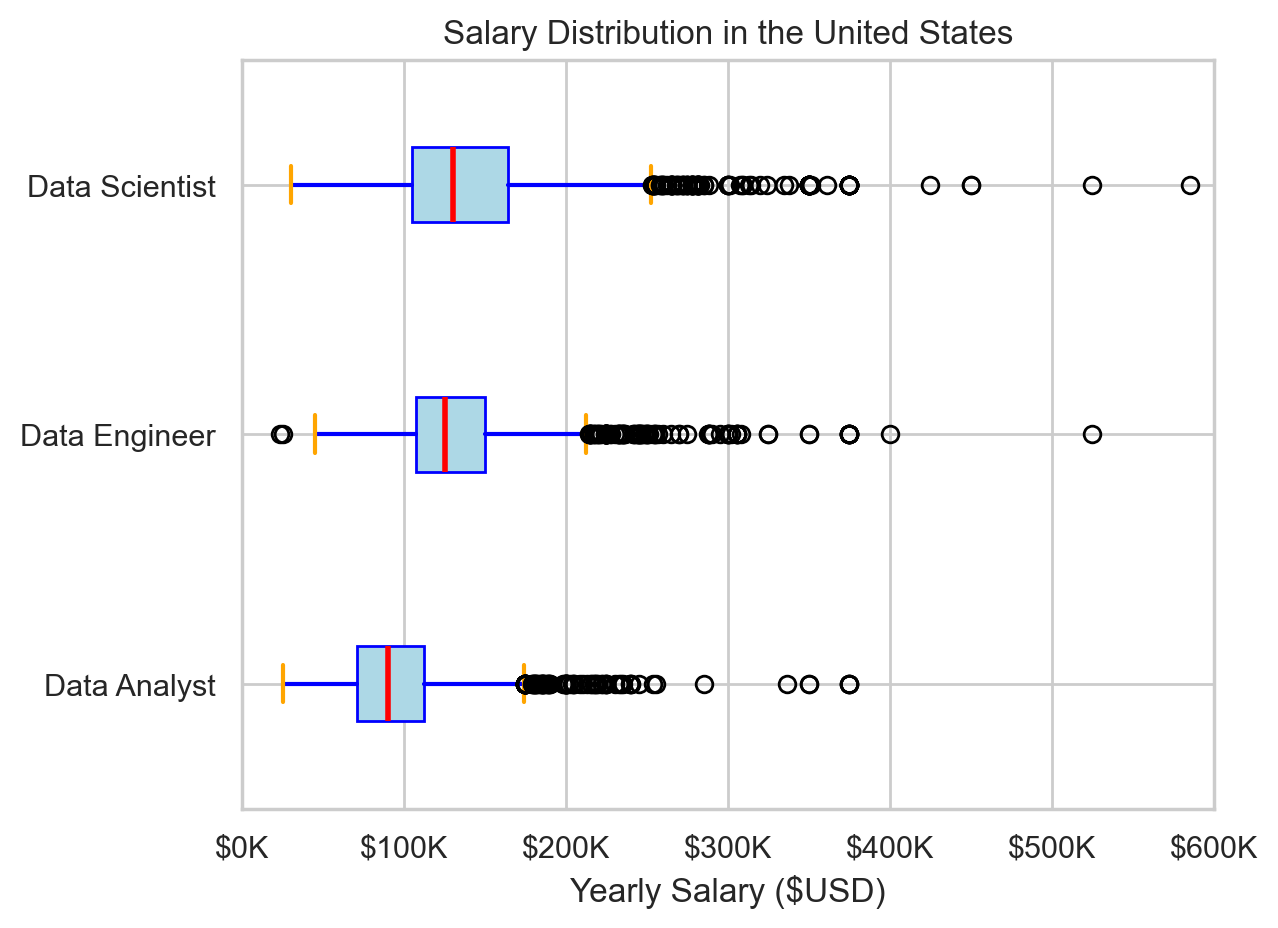

In [49]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(job_titles))].copy()
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, 
            tick_labels=job_titles, 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue', linewidth=1.5),
            capprops=dict(color='orange', linewidth=1.5)
)
plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.tight_layout()
plt.xlim(0, 600_000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.show()

Con seaborn abbiamo:

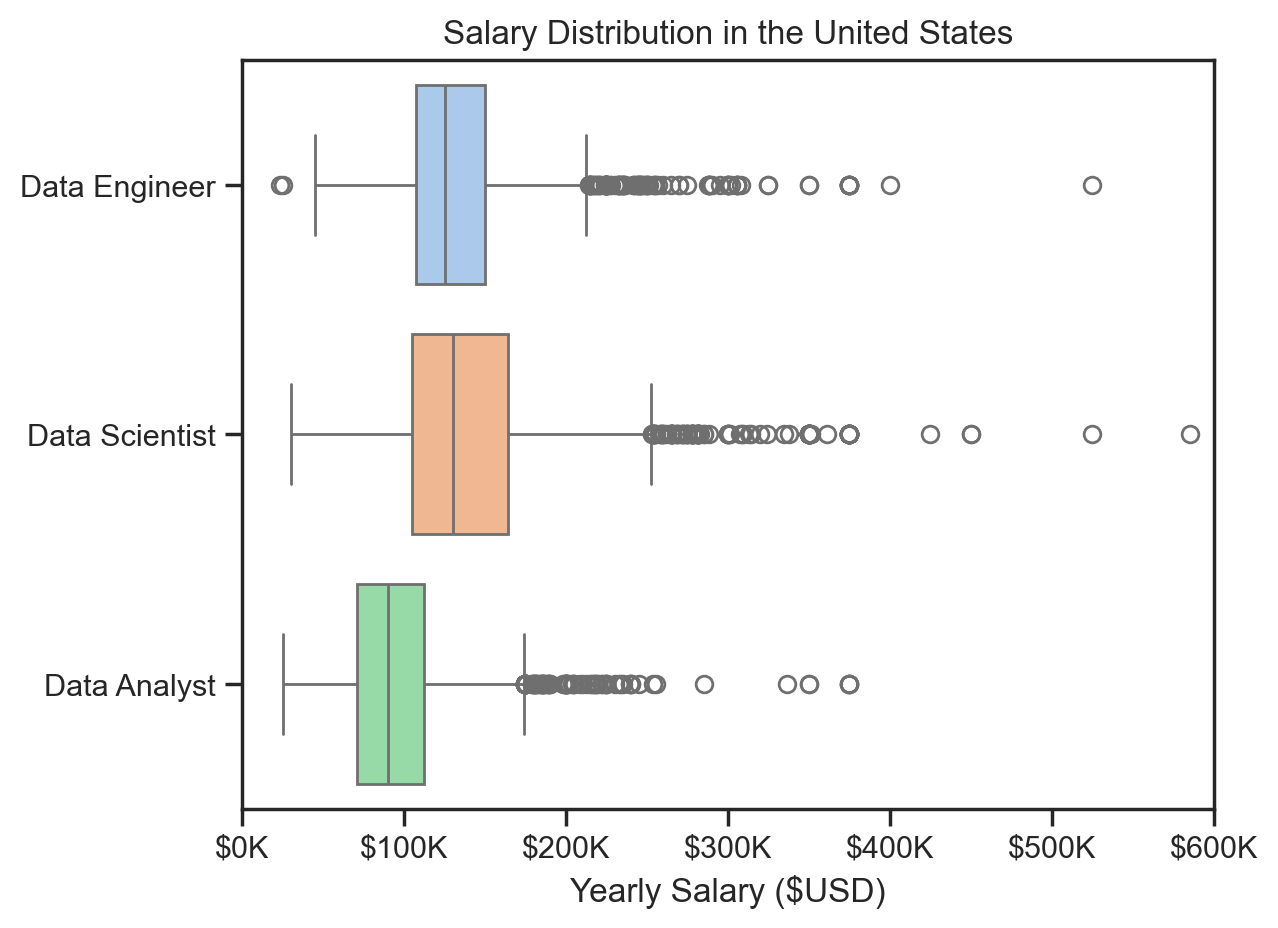

In [54]:
import seaborn as sns
sns.set_theme(style="ticks")
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short',hue='job_title_short', palette='pastel')
plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("")
plt.tight_layout()
plt.xlim(0, 600_000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.show()